Device: mps
Parameters: 8,577

  Epoch |       Loss |       L2 |    MaxErr |   MeanErr |  Elapsed
──────────────────────────────────────────────────────────────────
    500 |   4.41e+00 |   0.0632 |  7.13e-02 |  2.37e-02 |     7.0s
   1000 |   1.41e-02 |   0.0010 |  1.92e-03 |  3.70e-04 |    13.5s
   1500 |   3.29e-03 |   0.0004 |  5.60e-04 |  1.40e-04 |    19.9s
   2000 |   1.33e-03 |   0.0002 |  2.35e-04 |  6.61e-05 |    26.2s
   2500 |   7.32e-04 |   0.0002 |  2.18e-04 |  6.12e-05 |    33.1s

  Early stop at epoch 2500 (patience 3 reached)

Final L2 error  : 1.5998e-04
Final mean error: 6.1183e-05
Total time      : 33.1s


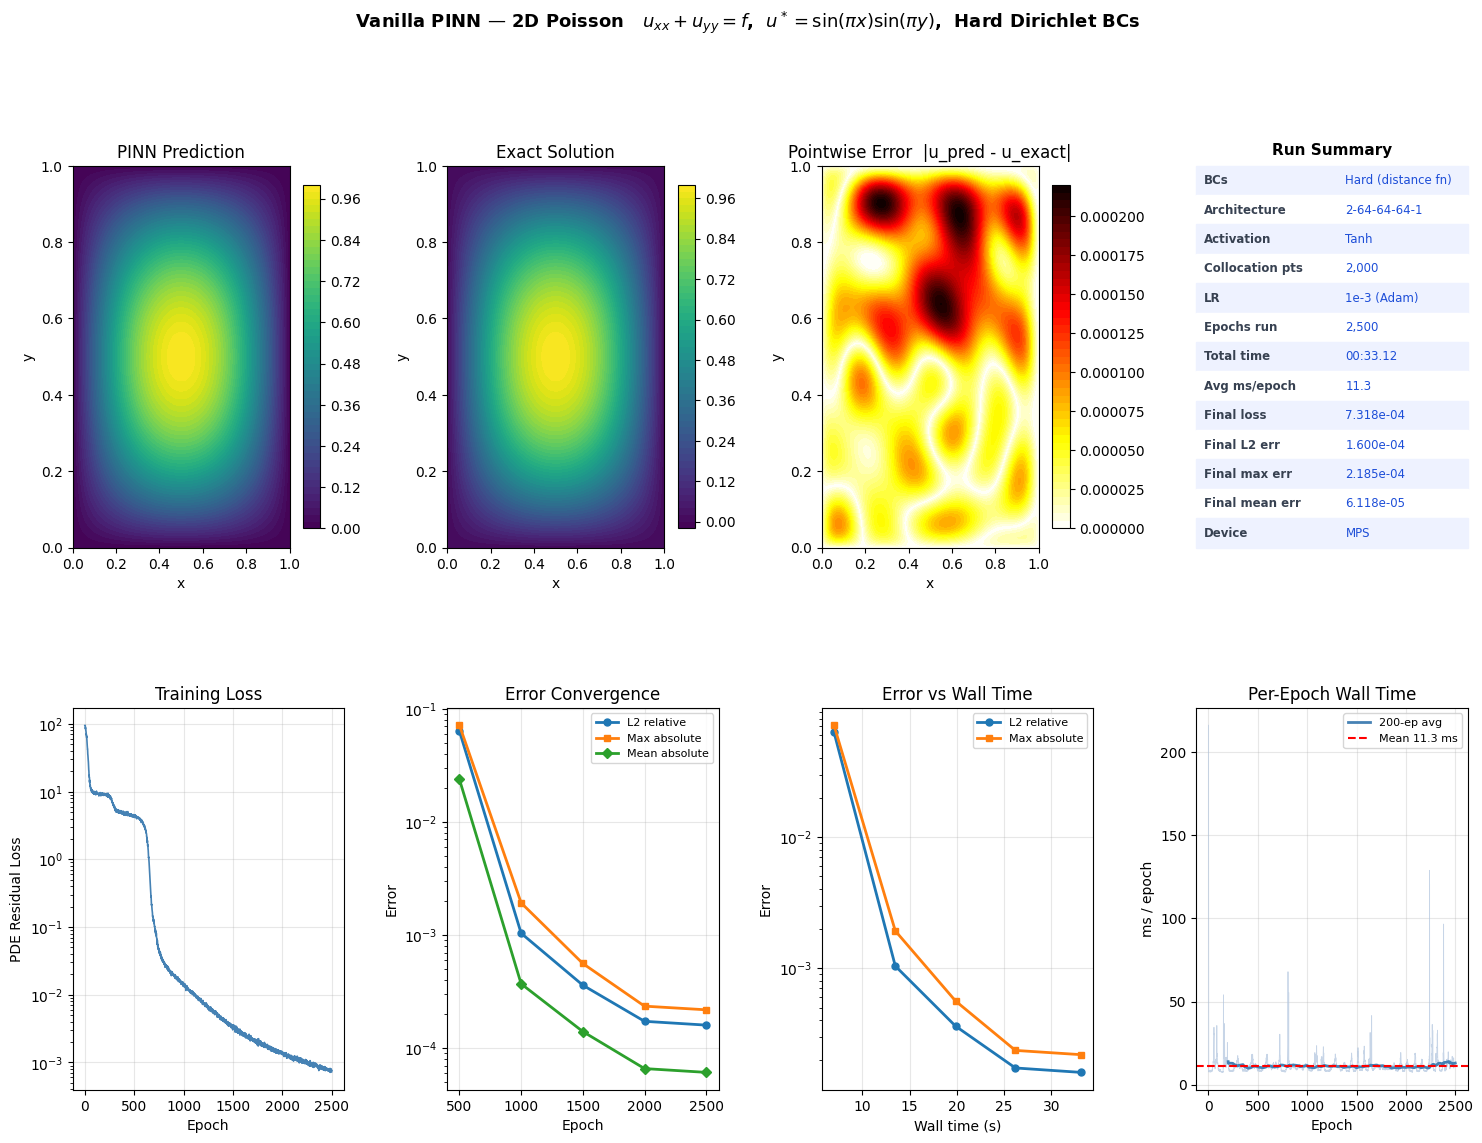

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

torch.manual_seed(42)
np.random.seed(42)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(42)
else:
    device = torch.device("cpu")
print(f"Device: {device}")


# ── Model ─────────────────────────────────────────────────────────────────────
class PINN(nn.Module):
    def __init__(self, layers=[2, 64, 64, 64, 1]):
        super().__init__()
        net = []
        for i in range(len(layers) - 1):
            net.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                net.append(nn.Tanh())
        self.net = nn.Sequential(*net)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def distance_fn(self, x, y):
        """Hard Dirichlet BC: zero on all four walls by construction."""
        return x * (1.0 - x) * y * (1.0 - y)

    def forward(self, x, y):
        N = self.net(torch.cat([x, y], dim=1))
        return N * self.distance_fn(x, y)


# ── PDE helpers ───────────────────────────────────────────────────────────────
def u_exact(x, y):
    pi = torch.tensor(torch.pi, device=x.device)
    return torch.sin(pi * x) * torch.sin(pi * y)


def pde_residual(model, x, y):
    u    = model(x, y)
    u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),
                                create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True, retain_graph=True)[0]
    u_y  = torch.autograd.grad(u,   y, grad_outputs=torch.ones_like(u),
                                create_graph=True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y),
                                create_graph=True, retain_graph=True)[0]
    pi   = torch.tensor(torch.pi, device=x.device)
    f    = -2.0 * pi**2 * torch.sin(pi * x) * torch.sin(pi * y)
    return u_xx + u_yy - f


def sample_interior(N):
    pts = torch.rand(N, 2, device=device)
    x   = pts[:, 0:1].requires_grad_(True)
    y   = pts[:, 1:2].requires_grad_(True)
    return x, y


# ── Metrics ───────────────────────────────────────────────────────────────────
@torch.no_grad()
def compute_metrics(model, N=200):
    lin      = torch.linspace(0, 1, N, device=device)
    X, Y     = torch.meshgrid(lin, lin, indexing='ij')
    xf, yf   = X.reshape(-1, 1), Y.reshape(-1, 1)
    u_pred   = model(xf, yf)
    u_true   = u_exact(xf, yf)
    l2       = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()
    max_err  = torch.max(torch.abs(u_pred - u_true)).item()
    mean_err = torch.mean(torch.abs(u_pred - u_true)).item()
    return l2, max_err, mean_err


# ── Training ──────────────────────────────────────────────────────────────────
def train(model, n_epochs=5000, N_int=2000, lr=1e-3, log_every=500,
          stop_l2=1e-3, stop_loss=1e-6, patience=3):
    """
    Hard BCs via distance function — only PDE residual loss.
    Early stopping when L2 < stop_l2 OR loss < stop_loss
    holds for `patience` consecutive checkpoints.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    hist = dict(loss=[], l2=[], max_err=[], mean_err=[],
                cum_time=[], epoch_ms=[])
    pat_cnt = 0
    t0      = time.perf_counter()

    hdr = (f"{'Epoch':>7} | {'Loss':>10} | {'L2':>8} |"
           f" {'MaxErr':>9} | {'MeanErr':>9} | {'Elapsed':>8}")
    print(hdr)
    print("─" * len(hdr))

    for ep in range(1, n_epochs + 1):
        t_ep = time.perf_counter()
        model.train()
        optimizer.zero_grad()

        x, y = sample_interior(N_int)
        loss = torch.mean(pde_residual(model, x, y) ** 2)
        loss.backward()
        optimizer.step()

        ep_ms = (time.perf_counter() - t_ep) * 1e3
        hist['loss'].append(loss.item())
        hist['epoch_ms'].append(ep_ms)

        if ep % log_every == 0:
            model.eval()
            l2, mx, mn = compute_metrics(model)
            elapsed     = time.perf_counter() - t0
            hist['l2'].append(l2)
            hist['max_err'].append(mx)
            hist['mean_err'].append(mn)
            hist['cum_time'].append(elapsed)

            print(f"{ep:>7} | {loss.item():>10.2e} | {l2:>8.4f} |"
                  f" {mx:>9.2e} | {mn:>9.2e} | {elapsed:>7.1f}s")

            # ── early stopping ─────────────────────────────────────────────
            if l2 < stop_l2 or loss.item() < stop_loss:
                pat_cnt += 1
                if pat_cnt >= patience:
                    print(f"\n  Early stop at epoch {ep} "
                          f"(patience {patience} reached)")
                    break
            else:
                pat_cnt = 0

    hist['total']    = time.perf_counter() - t0
    hist['final_ep'] = ep
    return hist


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_results(model, hist):
    N   = 200
    lin = torch.linspace(0, 1, N, device=device)
    X, Y = torch.meshgrid(lin, lin, indexing='ij')
    xf, yf = X.reshape(-1, 1), Y.reshape(-1, 1)

    with torch.no_grad():
        U_pred = model(xf, yf).reshape(N, N).cpu().numpy()
        U_true = u_exact(xf, yf).reshape(N, N).cpu().numpy()
    Err  = np.abs(U_pred - U_true)
    Xnp, Ynp = X.cpu().numpy(), Y.cpu().numpy()

    ep_arr  = np.arange(1, len(hist['loss']) + 1)
    eval_ep = np.arange(1, len(hist['l2']) + 1) * \
              (hist['final_ep'] / len(hist['l2']))
    ep_ms   = np.array(hist['epoch_ms'])

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

    # ── Row 0: solution fields (3 panels) + summary table ─────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    c1  = ax1.contourf(Xnp, Ynp, U_pred, levels=50, cmap='viridis')
    plt.colorbar(c1, ax=ax1, shrink=0.9)
    ax1.set_title('PINN Prediction')
    ax1.set_xlabel('x'); ax1.set_ylabel('y')

    ax2 = fig.add_subplot(gs[0, 1])
    c2  = ax2.contourf(Xnp, Ynp, U_true, levels=50, cmap='viridis')
    plt.colorbar(c2, ax=ax2, shrink=0.9)
    ax2.set_title('Exact Solution')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    ax3 = fig.add_subplot(gs[0, 2])
    c3  = ax3.contourf(Xnp, Ynp, Err, levels=50, cmap='hot_r')
    plt.colorbar(c3, ax=ax3, shrink=0.9)
    ax3.set_title('Pointwise Error  |u_pred - u_exact|')
    ax3.set_xlabel('x'); ax3.set_ylabel('y')

    # ── Summary table ──────────────────────────────────────────────────────
    ax_t = fig.add_subplot(gs[0, 3])
    ax_t.axis('off')
    ax_t.set_title('Run Summary', fontsize=11, fontweight='bold', pad=8)

    mins, secs = divmod(hist['total'], 60)
    rows = [
        ("BCs",             "Hard (distance fn)"),
        ("Architecture",    "2-64-64-64-1"),
        ("Activation",      "Tanh"),
        ("Collocation pts", f"{2000:,}"),
        ("LR",              "1e-3 (Adam)"),
        ("Epochs run",      f"{hist['final_ep']:,}"),
        ("Total time",      f"{int(mins):02d}:{secs:05.2f}"),
        ("Avg ms/epoch",    f"{ep_ms.mean():.1f}"),
        ("Final loss",      f"{hist['loss'][-1]:.3e}"),
        ("Final L2 err",    f"{hist['l2'][-1]:.3e}"),
        ("Final max err",   f"{hist['max_err'][-1]:.3e}"),
        ("Final mean err",  f"{hist['mean_err'][-1]:.3e}"),
        ("Device",          str(device).upper()),
    ]

    n = len(rows)
    for k, (label, val) in enumerate(rows):
        y_pos = 1.0 - (k + 0.5) / n
        bg    = '#EEF2FF' if k % 2 == 0 else '#FFFFFF'
        ax_t.add_patch(plt.Rectangle(
            (0, 1.0 - (k + 1) / n), 1.0, 1.0 / n,
            transform=ax_t.transAxes, color=bg, zorder=0, clip_on=False
        ))
        ax_t.text(0.03, y_pos, label, transform=ax_t.transAxes,
                  fontsize=8.5, va='center', color='#374151', fontweight='bold')
        ax_t.text(0.55, y_pos, val,   transform=ax_t.transAxes,
                  fontsize=8.5, va='center', color='#1D4ED8')

    ax_t.set_xlim(0, 1); ax_t.set_ylim(0, 1)
    for sp in ax_t.spines.values():
        sp.set_visible(False)

    # ── Row 1: training curves ─────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.semilogy(ep_arr, hist['loss'], lw=1.2, color='steelblue')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('PDE Residual Loss')
    ax4.set_title('Training Loss')
    ax4.grid(True, alpha=0.3)

    ax5 = fig.add_subplot(gs[1, 1])
    ax5.semilogy(eval_ep, hist['l2'],      'o-', lw=2, ms=5, label='L2 relative')
    ax5.semilogy(eval_ep, hist['max_err'], 's-', lw=2, ms=5, label='Max absolute')
    ax5.semilogy(eval_ep, hist['mean_err'],'D-', lw=2, ms=5, label='Mean absolute')
    ax5.set_xlabel('Epoch'); ax5.set_ylabel('Error')
    ax5.set_title('Error Convergence')
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.semilogy(hist['cum_time'], hist['l2'],      'o-', lw=2, ms=5,
                 label='L2 relative')
    ax6.semilogy(hist['cum_time'], hist['max_err'], 's-', lw=2, ms=5,
                 label='Max absolute')
    ax6.set_xlabel('Wall time (s)'); ax6.set_ylabel('Error')
    ax6.set_title('Error vs Wall Time')
    ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

    ax7 = fig.add_subplot(gs[1, 3])
    ax7.plot(ep_arr, ep_ms, lw=0.6, color='lightsteelblue', alpha=0.7)
    win = min(200, len(ep_ms) // 5)
    if win > 1:
        sm = np.convolve(ep_ms, np.ones(win) / win, mode='valid')
        ax7.plot(np.arange(win, len(ep_ms) + 1), sm,
                 lw=2.0, color='steelblue', label=f'{win}-ep avg')
    ax7.axhline(ep_ms.mean(), color='red', lw=1.5, ls='--',
                label=f'Mean {ep_ms.mean():.1f} ms')
    ax7.set_xlabel('Epoch'); ax7.set_ylabel('ms / epoch')
    ax7.set_title('Per-Epoch Wall Time')
    ax7.legend(fontsize=8); ax7.grid(True, alpha=0.3)

    fig.suptitle(
        r"Vanilla PINN — 2D Poisson   $u_{xx}+u_{yy}=f$,  "
        r"$u^*=\sin(\pi x)\sin(\pi y)$,  Hard Dirichlet BCs",
        fontsize=13, fontweight='bold', y=1.01
    )

    plt.savefig('vanilla_pinn_2d.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model  = PINN(layers=[2, 64, 64, 64, 1]).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {params:,}\n")

    hist = train(
        model,
        n_epochs  = 5000,
        N_int     = 2000,
        lr        = 1e-3,
        log_every = 500,
        stop_l2   = 1e-3,
        stop_loss = 1e-6,
        patience  = 3,
    )

    print(f"\nFinal L2 error  : {hist['l2'][-1]:.4e}")
    print(f"Final mean error: {hist['mean_err'][-1]:.4e}")
    print(f"Total time      : {hist['total']:.1f}s")

    plot_results(model, hist)